H0
68.18831037890374


Text(0.5, 1.0, '$\\Lambda\\mathrm{CDM}$')

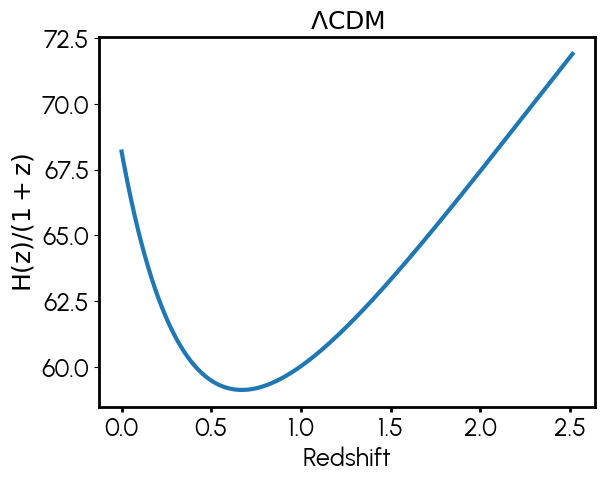

In [11]:
import numpy as np
import math
from astropy.cosmology import Planck18 as cosmo
import os 
import scipy
from matplotlib import pyplot as plt 
from matplotlib import font_manager

#Loading Fonts 

for fontpath in font_manager.findSystemFonts(fontpaths=None, fontext="ttf"):
    if 'Urbanist'.lower() in fontpath.lower():
        print(fontpath)

from matplotlib.font_manager import FontProperties

#Change it to your path
personal_path = "/home/hoelsczj/Library/static/"

#Get normal font and store it in `urbanist-Light`
font_path = personal_path + "Urbanist-Regular.ttf"
font_manager.fontManager.addfont(font_path)
urbanist= FontProperties(fname=font_path)

#Get bold font and store it in `urbanist_bold`
font_path = personal_path + "Urbanist-Bold.ttf"
font_manager.fontManager.addfont(font_path)
urbanist_bold = FontProperties(fname=font_path)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams['font.sans-serif'] = urbanist.get_name()
SMALL_SIZE = 18
MEDIUM_SIZE = 18
BIGGER_SIZE = 18

plt.rc('font', family="urbanist", size=SMALL_SIZE)          #Controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     #Fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE, lw=2)    #Fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    #Fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    #Fontsize of the tick labels
plt.rcParams['xtick.minor.width']=2   
plt.rcParams['xtick.major.width']=2 
plt.rc('legend', fontsize=SMALL_SIZE)    #Legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  #Fontsize of the figure title

from pyfonts import load_google_font
from pypalettes import load_cmap
cmap = load_cmap("PurpleGreens")

"""
Sets the initial conditions (densities at recombination)
"""

def InitialConditions_No_EDM(h):
    #Constants
    G = 6.67430e-11       #m^3 kg^-1 s^-2
    MetersPerMpc = 3.086e22  #meters per Mpc
    z_rec = 1090          #Redshift at recombination
    Reduced_Planck_Density = 5.155*(10**(96))/((8*math.pi)**2) 

    H0 = 100*h           #km/s/Mpc
    H0_SI = H0*1000/MetersPerMpc  #s^-1
    rho_crit_0 = 3*(H0_SI**2)/(8*np.pi*G)  #Critical density today, kg/m^3
    Omega_r = 4.15e-5/(h**2)  #Radiation density parameter (photons + neutrinos), from Dodelson 
    Omega_dm = 0.1179/(h**2) #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
    Omega_b = 0.02237/(h**2) #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
    Omega_Lambda = 1.0 - Omega_dm - Omega_b - Omega_r #Dark energy density for flatness 

    #Density parameters at z=1090
    rho_dm_initial = Omega_dm*rho_crit_0*((1 + z_rec)**3)  #Total dark matter density
    rho_b_initial = Omega_b*rho_crit_0*((1 + z_rec)**3)  #Baryonic matter density
    rho_r_initial = Omega_r*rho_crit_0*((1 + z_rec)**4)  #Radiation density
    rho_Lambda_initial = Omega_Lambda*rho_crit_0  #Dark energy density, is constant with redshift 

    #Converting to reduced Planck units 
    rho_dm_initial = rho_dm_initial/Reduced_Planck_Density
    rho_b_initial = rho_b_initial/Reduced_Planck_Density
    rho_r_initial = rho_r_initial/Reduced_Planck_Density
    rho_Lambda_initial = rho_Lambda_initial/Reduced_Planck_Density
    return rho_dm_initial, rho_b_initial, rho_r_initial, rho_Lambda_initial

"""
Here we compute H(z) for Lambda-CDM. 
"""

MetersPerParsec = 3.086*(10**(16))
MetersPerMpc = (10**6)*MetersPerParsec
SecondsperYear=31556952 
H0UnitConversion = 1000/(MetersPerParsec*1000000)

h = 0.6825 #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
H0 = 100*h           #km/s/Mpc
H0_SI = H0*1000/MetersPerMpc  #s^-1
Omega_dm = 0.1179/(h**2) #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
Omega_b = 0.02237/(h**2) #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
Omega_r = 4.15e-5/(h**2)  #Radiation density parameter (photons + neutrinos), from Dodelson 
Omega_Lambda = 1.0 - Omega_dm - Omega_b - Omega_r #Dark energy density for flatness 

rho_dm_initial, rho_b_initial, rho_r_initial, rho_Lambda_initial = InitialConditions_No_EDM(h)

#Friedman Equation 
def HLCDM(rho_dm, rho_b, rho_r, rho_Lambda):
    rho_total = rho_dm + rho_b + rho_r + rho_Lambda
    return math.sqrt((1/3)*(rho_total)) #No G or 8 pi because we are computing in reduced Planck units 

def RhoCriticalLCDM(rho_dm, rho_b, rho_r, rho_Lambda):
    Hval=HLCDM(rho_dm, rho_b, rho_r, rho_Lambda)
    return 3*Hval*Hval #No G or 8 pi because we are computing in reduced Planck units 

#Returns drho_r / dt
def drhordtLCDM(rho_dm, rho_b, rho_r, rho_Lambda):
    Hval=HLCDM(rho_dm, rho_b, rho_r, rho_Lambda)
    return -4*Hval*rho_r

#Returns drho_dm / dt (dark matter)
def drhodmdtLCDM(rho_dm, rho_b, rho_r, rho_Lambda):
    Hval=HLCDM(rho_dm, rho_b, rho_r, rho_Lambda)
    return -3*Hval*rho_dm

#Returns drho_b / dt (baryonic matter)
def drhobdtLCDM(rho_dm, rho_b, rho_r, rho_Lambda):
    Hval=HLCDM(rho_dm, rho_b, rho_r, rho_Lambda)
    return -3*Hval*rho_b

#Setting initial conditions (at z = 1090, or cosmic time of about 372,200 years)
rho_dm = rho_dm_initial
rho_b = rho_b_initial
rho_r = rho_r_initial
rho_Lambda = rho_Lambda_initial
Reduced_Planck_Time_Per_Second = 1.85489*(10**(43))/math.sqrt(8*math.pi)
t = 372200*SecondsperYear #converted from years to seconds 
t = t*Reduced_Planck_Time_Per_Second #Converted from seconds to reduced Planck units 
z=1090
ScaleFactor = 1/(1+1090)
dt = 1000*SecondsperYear #dt of 1,000 years, converted to seconds 
dt = dt*Reduced_Planck_Time_Per_Second #Converting from seconds to reduced Planck units 

HList_No_EDM=[] #Creating empty lists to store output 
zList_No_EDM=[]

#Euler's method, using it for simplicity
while z>0:
    rho_r_old = rho_r
    rho_dm_old = rho_dm 
    rho_b_old = rho_b
    rho_r = rho_r + dt*drhordtLCDM(rho_dm_old, rho_b_old, rho_r_old, rho_Lambda)
    rho_dm = rho_dm + dt*drhodmdtLCDM(rho_dm_old, rho_b_old, rho_r_old, rho_Lambda)
    rho_b = rho_b + dt*drhobdtLCDM(rho_dm_old, rho_b_old, rho_r_old, rho_Lambda)
    t = t + dt

    ScaleFactor = ScaleFactor + ScaleFactor*(dt/Reduced_Planck_Time_Per_Second)*HLCDM(rho_dm_old, rho_b_old, rho_r_old, rho_Lambda)*(Reduced_Planck_Time_Per_Second)
    z = (1/ScaleFactor)-1 #Computing redshift from scale factor 
    
    HList_No_EDM.append(HLCDM(rho_dm, rho_b, rho_r, rho_Lambda)*Reduced_Planck_Time_Per_Second/H0UnitConversion)
    zList_No_EDM.append(z)

print("H0") #printing Hubble constant, H(z=0).
print(HList_No_EDM[-1])

H1pzList_No_EDM=[]
for index in range(len(HList_No_EDM)):
    H1pzList_No_EDM.append(HList_No_EDM[index]/(1+zList_No_EDM[index]))

plt.plot(zList_No_EDM[-11200000:], H1pzList_No_EDM[-11200000:], linewidth=3)
plt.xlabel('Redshift')
plt.ylabel(r'$\rm{H}(z)/(1+z)$')
plt.title(r'$\Lambda\mathrm{CDM}$') #Plotting Hubble parameter evolution wrt redshift 


Note: Since our goal is to show that H(z) from our model can map onto that of the model in the work of Agrawal et al., we compute H(z) for LambdaCDM as appropriate to their work, where they have H0 of 68.25 km sec^-1 Mpc^-1 for LambdaCDM. We then plot the ratio of H(z) from our Cascade to H(z) from LambdaCDM. Other works may quote a slightly different H0 for LambdaCDM. 

In [12]:
def InitialConditions(h, FractionA):
    #Constants
    G = 6.67430e-11       #m^3 kg^-1 s^-2
    MetersPerMpc = 3.086e22  #meters per Mpc
    z_rec = 1090          #Redshift at recombination
    Reduced_Planck_Density = 5.155*(10**(96))/((8*math.pi)**2) 

    H0 = 100*h           #km/s/Mpc
    H0_SI = H0*1000/MetersPerMpc  #s^-1
    rho_crit_0 = 3*(H0_SI**2)/(8*np.pi*G)  #Critical density today, kg/m^3
    Omega_r = 4.15e-5/(h**2)  #Radiation density parameter (photons + neutrinos), from Dodelson 
    Omega_dm = 0.1179/(h**2) #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
    Omega_b = 0.02237/(h**2) #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
    Omega_matter_total = Omega_dm + Omega_b #Dark matter + baryonic matter 
    Omega_EDM = Omega_dm*FractionA #FractionA sets fraction of DM at recombination that lives in our decay chain.
    Omega_m = Omega_matter_total - Omega_EDM #Baryons + dark matter not living in our decay chain (i.e. dark matter that is not field A or B.)

    # Density parameters at z=1090
    rho_EDM_initial = Omega_EDM*rho_crit_0*((1 + z_rec)**3)  #Total exotic dark matter density (the cascade fields A and B)
    rho_m_initial = Omega_m*rho_crit_0*((1 + z_rec)**3)  #Total (non-exotic dark matter) matter density
    rho_r_initial = Omega_r*rho_crit_0*((1 + z_rec)**4)  #Radiation density
    
    rho_EDM_initial = rho_EDM_initial/Reduced_Planck_Density #Converting from SI to reduced Planck units, to match the convention of Agrawal et al.
    rho_m_initial = rho_m_initial/Reduced_Planck_Density
    rho_r_initial = rho_r_initial/Reduced_Planck_Density
        
    return rho_EDM_initial, rho_m_initial, rho_r_initial

def ExoticDarkMatter(DecayRate, FractionA):
    #Constants
    MetersPerParsec = 3.086e16  #meters per parsec
    MetersPerMpc = (10**6)*MetersPerParsec  #meters per Mpc
    H0UnitConversion = 1000/(MetersPerMpc)
    SecondsperYear=31556952
    Reduced_Planck_Time_Per_Second = 1.85489*(10**(43))/math.sqrt(8*math.pi)

    h_sample = 0.6912 #From Table II in the work of Agrawal, Obied, and Vafa, arxiv 1906.08261
        
    rho_A, rho_m, rho_r = InitialConditions(h_sample, FractionA) #Obtaining densities at z = 1090 
    rho_B = 0 #Field B is not present until it is produced via decays
    
    c_coeff = 0.1 #Value used by Agrawal et al.
    b_coeff = 50 #Value used by Agrawal et al.
    ctilde = 0.5 #Here we had to adjust the value from that used by Agrawal et al., as only a fraction of the dark matter couples to dark energy here (rather than all of the dark matter).
    #Below we have values for Phi and the first time derivative of Phi at z = 15, where the field exits "tracker" behavior. 
    PhiDot = math.sqrt((3/(b_coeff*b_coeff))*((rho_A + rho_B + rho_m)*((1+15)/(1+1090))**3 + rho_r*((1+15)/(1+1090))**4 ) )
    Phi=0 
    K1 = 0.81374*(10**(-120)) #These set the values for coefficients in the potential for the quintessence field.
    K2 = 0.81374*(10**(-120))

    #Friedman Equation 
    def H(rho_A, rho_B, rho_m, rho_r, rho_Phi):
        rho_total = rho_A + rho_B + rho_m + rho_r + rho_Phi
        return math.sqrt((1/3)*(rho_total)) #No G or 8 pi because we are computing in reduced Planck units 
    
    #Returns drho_r / dt 
    def drhordt(rho_A, rho_B, rho_m, rho_r, rho_Phi):
        Hval=H(rho_A, rho_B, rho_m, rho_r, rho_Phi)
        return -4*Hval*rho_r
    
    #Returns drho_m / dt 
    def drhomdt(rho_A, rho_B, rho_m, rho_r, rho_Phi):
        Hval=H(rho_A, rho_B, rho_m, rho_r, rho_Phi)
        return -3*Hval*rho_m
    
    #Returns drho_A / dt 
    def drhoAdt(rho_A, rho_B, rho_m, rho_r, rho_Phi, Gamma_A):
        w_A = 0 #Eqn of state parameter 
        Hval=H(rho_A, rho_B, rho_m, rho_r, rho_Phi)
        return -3*Hval*rho_A - 3*Hval*w_A*rho_A - Gamma_A*rho_A
    
    #Returns drho_B / dt
    def drhoBdt(rho_A, rho_B, rho_m, rho_r, rho_Phi, Gamma_A, PhiDot):
        w_B = 0 #Eqn of state parameter 
        Hval=H(rho_A, rho_B, rho_m, rho_r, rho_Phi)
        return -3*Hval*rho_B - 3*Hval*w_B*rho_B + Gamma_A*rho_A - ctilde*PhiDot*rho_B

    #Returns d^2 phi / dt^2
    def PhiDotDot(rho_A, rho_B, rho_m, rho_r, rho_Phi, Phi, PhiDot, b_coeff, c_coeff, ctilde, K1, K2, Gamma_A):
        Hval=H(rho_A, rho_B, rho_m, rho_r, rho_Phi)
        return -3*Hval*PhiDot + b_coeff*K1*math.exp(-b_coeff*Phi) + c_coeff*K2*math.exp(-c_coeff*Phi) + ctilde*rho_B

    HList_EDM=[]
    zList_EDM=[] #Creating empty lists to store output 

    t = 372200*SecondsperYear #converted from years to seconds 
    t = t*Reduced_Planck_Time_Per_Second #converting from seconds to reduced Planck units 
    z=1090
    ScaleFactor = 1/(1+1090)
    dt = 1000*SecondsperYear #dt of 1,000 years
    dt = dt*Reduced_Planck_Time_Per_Second #converting to reduced Planck units 
    rho_Phi = 0 #Initializing the variable. This will be overwritten below. 

    #Euler's method, using it bc it is simple 
    while z>0:
        rho_r_old = rho_r
        rho_m_old = rho_m 
        rho_A_old = rho_A 
        rho_B_old = rho_B 
        PhiDot_old = PhiDot
        Phi_old = Phi
        rho_Phi_old = rho_Phi

        if z >=15: #Here the quintessence field is assumed to exhibit "tracker" behavior for z > 15.
            Gamma_A = 0 #No decays of A to B yet for z > 15
            w_background = (1/3)*(rho_r/(rho_A + rho_B + rho_m + rho_r)) #This equation of state parameter is not exactly zero because there is some radiation in the mix.
            rho_Phi = (3*(1+w_background)/(b_coeff**2))*(rho_A + rho_B + rho_m + rho_r)
        if 0 <= z < 15: #Decays of A to B begin
            Gamma_A = DecayRate/Reduced_Planck_Time_Per_Second #converted to reduced Planck units 
        
        rho_r = rho_r_old + dt*drhordt(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi_old)
        rho_m = rho_m_old + dt*drhomdt(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi_old)

        #Here we have decays, where we prevent any negative densities. (Decay stops when decaying field is depleted totally.)
        if (rho_A_old + dt*drhoAdt(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi_old, Gamma_A)) > 0:
            rho_A = rho_A_old + dt*drhoAdt(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi_old, Gamma_A)
        else:
            rho_A = 0
            rho_A_old = 0 #Prevents sourcing B from A when this would result in negative rho_A

        if (rho_B_old + dt*drhoBdt(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi_old, Gamma_A, PhiDot)) > 0:
            rho_B = rho_B_old + dt*drhoBdt(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi_old, Gamma_A, PhiDot)
        else:
            rho_B = 0
            rho_B_old = 0 #Prevents sourcing Phi from B when this would result in negative rho_B

        if 0 <= z < 15: #Evolving dark energy from quintessence equations of motion 
            PhiDot = PhiDot_old + dt*PhiDotDot(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi_old, Phi_old, PhiDot_old, b_coeff, c_coeff, ctilde, K1, K2, Gamma_A)
            Phi = Phi_old + PhiDot_old*dt
            rho_Phi_old = rho_Phi
            rho_Phi = (1/2)*(PhiDot*PhiDot) + K1*math.exp(-b_coeff*Phi) + K2*math.exp(-c_coeff*Phi)

        t = t + dt

        ScaleFactor = ScaleFactor + ScaleFactor*(dt/Reduced_Planck_Time_Per_Second)*H(rho_A_old, rho_B_old, rho_m_old, rho_r_old, rho_Phi)*Reduced_Planck_Time_Per_Second
        z = (1/ScaleFactor)-1 #Computing redshift from the scale factor 
        
        HList_EDM.append(H(rho_A, rho_B, rho_m, rho_r, rho_Phi)*Reduced_Planck_Time_Per_Second/H0UnitConversion)
        zList_EDM.append(z)

    H0New = H(rho_A, rho_B, rho_m, rho_r, rho_Phi)*Reduced_Planck_Time_Per_Second/H0UnitConversion
    print('H0 (km/secMpc): ') #printing the Hubble constant H(z = 0).
    print(H0New)
   
    H1pzList_EDM=[] #Dividing H by 1+z, useful for plotting later. 
    for index in range(len(HList_EDM)):
        H1pzList_EDM.append(HList_EDM[index]/(1+zList_EDM[index]))

    #Here I apply a cubic spline interpolation, useful for plotting things.
    Interpolated_H = scipy.interpolate.CubicSpline(np.flip(zList_EDM), np.flip(HList_EDM), axis=0, extrapolate=None)

    return zList_EDM, H0New, H1pzList_EDM, Interpolated_H


In [13]:
DecayRate = 10**(-15) #sec^-1
FractionA = 0.2 #20 percent of dark matter is field A at z = 1090.
#Here I apply a cubic spline interpolation, useful for plotting things below.
#Note that np.flip is used becuase the interpolator will throw an error if you feed it a list of z-values that goes from large numbers to small ones. 
Interpolated_H_No_EDM=scipy.interpolate.CubicSpline(np.flip(zList_No_EDM), np.flip(HList_No_EDM), axis=0, extrapolate=None)
Output = ExoticDarkMatter(DecayRate, FractionA)
Interpolated_H_EDM = Output[3]

H0 (km/secMpc): 
69.08218222818802


In [14]:
#Here I am loading H(z) from the work of Agrawal et al. I have manually converted their plot to lists of values by using an online plot digitizing tool. I am interpolating the data using cubic splines. 
z_Agrawal = [969767.1763033555, 345674.8682497425, 117309.58437388069, 40800.59569533394, 14190.585853290379, 5445.0285690556, 1989.1475178819444, 928.9674312259076, 356.45140060051966, 136.77293381792757, 43.11884855568132, 15.75193766032656, 10.897678325398303, 8.317637711026691, 6.83387695426612, 5.215956782987809, 4.39204548815022, 3.521005201684521, 2.687407322017546, 1.8141240973862374, 1.4905046433861953, 1.2550672356621626, 1.0830965062933233, 0.9120108393559088, 0.8066156921766129, 0.6792041417072701, 0.5861388235148876, 0.4698944608095045, 0.3767039401611081, 0.28751929322271125, 0.17592747067686962, 0.07447325321121687, 0.024660411856287222, 0.007046938612604425]
H_HLambdaCDM_Agrawal = [1.0008395175306921, 1.000811688642578, 1.0008395175306921, 1.0008673474804102, 1.0009508352063567, 1.0011178106582497, 1.0013126139366528, 1.0014517605004316, 1.0015909070642106, 1.0016187380755328, 1.0016465680252509, 1.001674396913365, 1.0012847871717467, 1.0004499077890738, 0.9996706861826291, 0.998668830286459, 0.9979452685794508, 0.9972495357605565, 0.9968042671811059, 0.9970269025324352, 0.9976391465637788, 0.9984461970583377, 0.999336735278843, 1.00047773455398, 1.001340444947975, 1.0025092762960381, 1.0037337664819335, 1.0051808909575541, 1.006488867807792, 1.007852504557466, 1.0097170687244232, 1.0115538029416622, 1.0123608534362212, 1.0126391465637787]
Interpolated_H_HLambdaCDM_Agrawal=scipy.interpolate.CubicSpline(np.flip(z_Agrawal), np.flip(H_HLambdaCDM_Agrawal), axis=0, extrapolate=None)

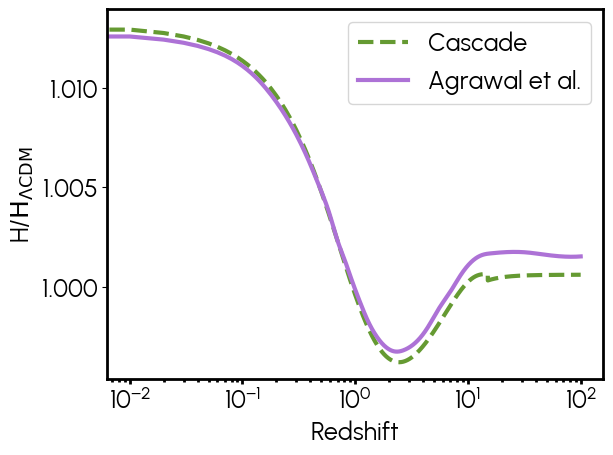

In [15]:
#Plotting H(z)/H(z)_LambdaCDM, to illustrate the effect on Hubble expansion
zList=np.linspace(0, 100, 10000) #Redshift values between 0 and 100, for plotting 
plt.plot(zList, Interpolated_H_EDM(zList)/Interpolated_H_No_EDM(zList), color=cmap(6), linestyle='dashed', linewidth = 3, label='Cascade')
plt.plot(zList, Interpolated_H_HLambdaCDM_Agrawal(zList), color=cmap(2), linewidth=3, linestyle='solid', label='Agrawal et al.')
plt.xlabel("Redshift")
plt.ylabel(r'H/$\mathrm{H}_{\Lambda\mathrm{CDM}}$')
plt.xscale("log")
plt.legend()
plt.show()